### Лабораторная работа 3: Реализация обхода в ширину из нескольких стартовых вершин (Multiple-Source BFS)

In [1]:
# !pip -q install python-graphblas numpy pandas matplotlib scipy

In [2]:
import time
import os
import glob
import pandas as pd
import numpy as np
import seaborn as sns

import warnings
from pathlib import Path
from collections import deque

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import scipy.sparse as sp
import networkx as nx

In [3]:
import graphblas as gb

gb.init("suitesparse", blocking=False)

from graphblas import Matrix, dtypes, monoid, agg, Vector, binary, semiring
from graphblas import semiring, binary, unary, monoid, op, replace
from graphblas.io import mmread

In [4]:
plt.style.use("default")
warnings.filterwarnings("ignore", category=FutureWarning)
print(gb.__version__)

2024.2.0


---

In [5]:
def ensure_square(A):
    if A.nrows != A.ncols:
        raise ValueError("adjacency matrix must be square")


def to_unweighted_bool(A):
    ensure_square(A)
    rows, cols, vals = A.to_coo()

    if len(rows) == 0:
        return Matrix(bool, A.nrows, A.ncols)

    keep = vals != 0
    if int(np.sum(keep)) == 0:
        return Matrix(bool, A.nrows, A.ncols)

    rows = rows[keep]
    cols = cols[keep]
    data = np.ones(len(rows), dtype=bool)

    return Matrix.from_coo(
        rows,
        cols,
        data,
        nrows=A.nrows,
        ncols=A.ncols,
        dtype=bool,
        dup_op=binary.lor,
    )


def prepare_starts(starts, n):
    cleaned = []
    used = set()

    for s in starts:
        s = int(s)
        if s < 0 or s >= n:
            raise ValueError(f"start vertex {s} out of range [0, {n})")
        if s not in used:
            used.add(s)
            cleaned.append(s)

    if len(cleaned) == 0:
        raise ValueError("need at least one start vertex")

    return np.array(cleaned, dtype=np.int64)


def make_frontier(starts_arr, n):
    k = len(starts_arr)
    rows = np.arange(k, dtype=np.int64)
    vals = np.ones(k, dtype=bool)
    return Matrix.from_coo(rows, starts_arr, vals, nrows=k, ncols=n, dtype=bool, dup_op=binary.lor)


def row_to_dense_with_fill(M, row_idx, fill_value):
    return M[row_idx, :].new().to_dense(fill_value=fill_value).astype(np.int64)


def graph_from_edges(n, edges):
    if len(edges) == 0:
        return Matrix(dtypes.INT64, n, n)

    rows = np.array([u for u, _ in edges], dtype=np.int64)
    cols = np.array([v for _, v in edges], dtype=np.int64)
    vals = np.ones(len(edges), dtype=np.int64)

    return Matrix.from_coo(
        rows,
        cols,
        vals,
        nrows=n,
        ncols=n,
        dtype=dtypes.INT64,
        dup_op=binary.any,
    )


def random_digraph_matrix(n, density, seed=0):
    if not (0.0 <= density <= 1.0):
        raise ValueError("density must be in [0, 1]")

    rng = np.random.default_rng(seed)
    target = int(density * n * (n - 1))

    if target <= 0:
        return Matrix(dtypes.INT64, n, n)

    rows_parts = []
    cols_parts = []
    need = target

    while need > 0:
        batch = max(need * 2, 1024)
        r = rng.integers(0, n, size=batch, dtype=np.int64)
        c = rng.integers(0, n, size=batch, dtype=np.int64)
        mask = r != c
        r = r[mask]
        c = c[mask]

        take = min(need, len(r))
        if take > 0:
            rows_parts.append(r[:take])
            cols_parts.append(c[:take])
            need -= take

    rows = np.concatenate(rows_parts) if rows_parts else np.array([], dtype=np.int64)
    cols = np.concatenate(cols_parts) if cols_parts else np.array([], dtype=np.int64)
    vals = np.ones(len(rows), dtype=np.int64)

    return Matrix.from_coo(
        rows,
        cols,
        vals,
        nrows=n,
        ncols=n,
        dtype=dtypes.INT64,
        dup_op=binary.any,
    )

def generate_random_graphs(sizes, densities, seeds=None):
    if seeds is None:
        seeds = [42] * max(len(sizes), len(densities))
    graphs = []
    for n in sizes:
        for d in densities:
            seed = seeds[0] if len(seeds) == 1 else seeds.pop(0)
            A = random_digraph_matrix(n, d, seed=seed)
            graphs.append({
                "name": f"rand_n{n}_d{d:.3f}_s{seed}",
                "A": A,
                "n": n,
                "density": d,
                "seed": seed
            })
    return graphs

def load_all_mtx_graphs(data_root="../data"):
    pattern = os.path.join(data_root, "*", "*.mtx")
    mtx_files = glob.glob(pattern)
    graphs = []
    for fpath in mtx_files:
        name = os.path.basename(fpath).replace(".mtx", "")
        try:
            A = mmread(fpath)
            if A.nrows != A.ncols:
                print(f"Пропускаем {name}: не квадратная матрица {A.nrows}x{A.ncols}")
                continue
            graphs.append({"name": name, "A": A, "n": A.nrows, "nnz": A.nvals})
        except Exception as e:
            print(f"Ошибка загрузки {fpath}: {e}")
    return graphs

def measure_time_for_graph(A, start_counts, funcs, n_repeats=3):
    n = A.nrows
    results = []
    for k in start_counts:
        if k > n:
            continue
        starts = np.random.choice(n, size=k, replace=False).tolist()
        for fname, f in funcs.items():
            times = []
            for _ in range(n_repeats):
                start_time = time.perf_counter()
                _ = f(A, starts)
                elapsed = time.perf_counter() - start_time
                times.append(elapsed)
            avg_time = np.mean(times)
            results.append({
                "function": fname,
                "n_vertices": n,
                "n_start": k,
                "avg_time_sec": avg_time,
                "std_time_sec": np.std(times) if n_repeats>1 else 0
            })
    return pd.DataFrame(results)

## MSBFS

In [6]:
def _msbfs_levels_matrix(A_bool, starts_arr, use_any_pair=False):
    n = A_bool.nrows
    k = len(starts_arr)

    frontier = make_frontier(starts_arr, n)
    levels = Matrix(dtypes.INT64, k, n)

    sr = semiring.any_pair if use_any_pair else semiring.lor_land
    level = 0

    while frontier.nvals > 0:
        levels(mask=frontier.S) << level

        next_frontier = Matrix(bool, k, n)
        next_frontier(~levels.S, replace=True) << frontier.mxm(A_bool, sr)

        frontier = next_frontier
        level += 1

    return levels


def _msbfs_parents_matrix(A_bool, starts_arr, use_any_first=False):
    n = A_bool.nrows
    k = len(starts_arr)

    frontier = make_frontier(starts_arr, n)
    visited = frontier.dup()

    parents = Matrix(dtypes.INT64, k, n)
    rows = np.arange(k, dtype=np.int64)
    vals = np.full(k, -1, dtype=np.int64)
    parents.build(rows, starts_arr, vals, dup_op=binary.min)

    sr = semiring.any_first if use_any_first else semiring.min_first

    while frontier.nvals > 0:
        frontier_idx = frontier.apply(gb.indexunary.colindex, right=0).new(dtype=dtypes.INT64)

        next_parents = Matrix(dtypes.INT64, k, n)
        next_parents(~visited.S, replace=True) << frontier_idx.mxm(A_bool, sr)

        if next_parents.nvals == 0:
            break

        parents(mask=next_parents.S) << next_parents
        visited(mask=next_parents.S) << True

        frontier = Matrix(bool, k, n)
        frontier(mask=next_parents.S) << True

    return parents


def msbfs_levels(A, starts):
    A_bool = to_unweighted_bool(A)
    starts_arr = prepare_starts(starts, A_bool.nrows)

    levels_matrix = _msbfs_levels_matrix(A_bool, starts_arr, use_any_pair=False)

    result = []
    for i, s in enumerate(starts_arr):
        levels = row_to_dense_with_fill(levels_matrix, i, fill_value=-1)
        result.append((int(s), levels))
    return result


def msbfs_levels_any_pair(A, starts):
    A_bool = to_unweighted_bool(A)
    starts_arr = prepare_starts(starts, A_bool.nrows)
    levels_matrix = _msbfs_levels_matrix(A_bool, starts_arr, use_any_pair=True)

    result = []
    for i, s in enumerate(starts_arr):
        levels = row_to_dense_with_fill(levels_matrix, i, fill_value=-1)
        result.append((int(s), levels))
    return result


def msbfs_parents(A, starts):
    A_bool = to_unweighted_bool(A)
    starts_arr = prepare_starts(starts, A_bool.nrows)

    parents_matrix = _msbfs_parents_matrix(A_bool, starts_arr, use_any_first=False)

    result = []
    for i, s in enumerate(starts_arr):
        parents = row_to_dense_with_fill(parents_matrix, i, fill_value=-2)
        result.append((int(s), parents))
    return result


def msbfs_parents_any_first(A, starts):
    A_bool = to_unweighted_bool(A)
    starts_arr = prepare_starts(starts, A_bool.nrows)
    parents_matrix = _msbfs_parents_matrix(A_bool, starts_arr, use_any_first=True)

    result = []
    for i, s in enumerate(starts_arr):
        parents = row_to_dense_with_fill(parents_matrix, i, fill_value=-2)
        result.append((int(s), parents))
    return result

### Примеры

In [7]:
demo_edges = [
    (0, 1), (0, 2),
    (1, 3), (2, 3),
    (1, 4), (2, 4),
    (4, 5),
]

A_demo = graph_from_edges(7, demo_edges)
starts_demo = [0, 2]

levels_demo = msbfs_levels(A_demo, starts_demo)
parents_demo = msbfs_parents(A_demo, starts_demo)
levels_demo_bonus = msbfs_levels_any_pair(A_demo, starts_demo)
parents_demo_bonus = msbfs_parents_any_first(A_demo, starts_demo)

print("levels (lor_land):")
for s, arr in levels_demo:
    print(f"start={s}: {arr}")

print()
print("parents (min_first):")
for s, arr in parents_demo:
    print(f"start={s}: {arr}")

print()
print("levels bonus (any_pair):")
for s, arr in levels_demo_bonus:
    print(f"start={s}: {arr}")

print()
print("parents bonus (any_first):")
for s, arr in parents_demo_bonus:
    print(f"start={s}: {arr}")

levels (lor_land):
start=0: [ 0  1  1  2  2  3 -1]
start=2: [-1 -1  0  1  1  2 -1]

parents (min_first):
start=0: [-1  0  0  1  1  4 -2]
start=2: [-2 -2 -1  2  2  4 -2]

levels bonus (any_pair):
start=0: [ 0  1  1  2  2  3 -1]
start=2: [-1 -1  0  1  1  2 -1]

parents bonus (any_first):
start=0: [-1  0  0  2  2  4 -2]
start=2: [-2 -2 -1  2  2  4 -2]


### Тесты

In [8]:
def reference_levels_and_min_parents(n, edges, start):
    out_adj = [[] for _ in range(n)]
    in_adj = [[] for _ in range(n)]

    for u, v in edges:
        out_adj[u].append(v)
        in_adj[v].append(u)

    levels = [-1] * n
    q = deque([start])
    levels[start] = 0

    while q:
        u = q.popleft()
        for v in out_adj[u]:
            if levels[v] == -1:
                levels[v] = levels[u] + 1
                q.append(v)

    parents = [-2] * n
    parents[start] = -1

    for v in range(n):
        if v == start or levels[v] == -1:
            continue
        candidates = [u for u in in_adj[v] if levels[u] == levels[v] - 1]
        if len(candidates) > 0:
            parents[v] = min(candidates)

    return np.array(levels, dtype=np.int64), np.array(parents, dtype=np.int64)


def edges_from_bool_matrix(A_bool):
    rows, cols, _ = A_bool.to_coo()
    return [(int(u), int(v)) for u, v in zip(rows, cols)]


def run_tests():

    n1 = 5
    e1 = [(0, 1), (0, 2), (1, 3), (2, 3), (1, 4), (2, 4)]
    A1 = graph_from_edges(n1, e1)
    p1 = msbfs_parents(A1, [0])[0][1]
    assert p1[3] == 1
    assert p1[4] == 1

    n2 = 6
    e2 = [(0, 1), (1, 2), (3, 4)]
    A2 = graph_from_edges(n2, e2)
    l2 = msbfs_levels(A2, [0])[0][1]
    p2 = msbfs_parents(A2, [0])[0][1]
    assert l2[3] == -1 and l2[5] == -1
    assert p2[3] == -2 and p2[5] == -2
    assert p2[0] == -1

    rng = np.random.default_rng(2026)
    for seed in range(12):
        n = 12 + (seed % 6)
        A_rand = random_digraph_matrix(n=n, density=0.12, seed=seed)
        A_bool = to_unweighted_bool(A_rand)
        edges = edges_from_bool_matrix(A_bool)
        edge_set = set(edges)

        starts = rng.choice(n, size=min(4, n), replace=False)

        lev_base = msbfs_levels(A_rand, starts)
        lev_bonus = msbfs_levels_any_pair(A_rand, starts)
        par_base = msbfs_parents(A_rand, starts)
        par_bonus = msbfs_parents_any_first(A_rand, starts)

        starts_arr = prepare_starts(starts, n)
        for i, s in enumerate(starts_arr):
            ref_levels, ref_parents = reference_levels_and_min_parents(n, edges, int(s))

            assert np.array_equal(lev_base[i][1], ref_levels)
            assert np.array_equal(lev_bonus[i][1], ref_levels)
            assert np.array_equal(par_base[i][1], ref_parents)

            pb = par_bonus[i][1]
            assert pb[s] == -1
            for v in range(n):
                if v == s:
                    continue
                if ref_levels[v] == -1:
                    assert pb[v] == -2
                else:
                    u = int(pb[v])
                    assert 0 <= u < n
                    assert (u, v) in edge_set
                    assert ref_levels[u] == ref_levels[v] - 1

    print("Все тесты пройдены!")


run_tests()

Все тесты пройдены!


---

### Эксперимент с mtx

Графы брались с сайта [SuiteSparse Matrix Collection](https://sparse.tamu.edu/)

In [9]:
print("Загрузка реальных графов...")
real_graphs = load_all_mtx_graphs("../data")
print(f"Загружено графов: {len(real_graphs)}")

real_graphs = [g for g in real_graphs if 100 <= g["n"] <= 50000]
real_graphs = sorted(real_graphs, key=lambda x: x["n"])[:5]
print("Выбранные графы:", [(g["name"], g["n"], g["nnz"]) for g in real_graphs])

funcs = {
    "MSBFS-Levels (lor_land)": lambda A, s: msbfs_levels(A, s),
    "MSBFS-Levels (any_pair)": lambda A, s: msbfs_levels_any_pair(A, s),
    "MSBFS-Parents (min_first)": lambda A, s: msbfs_parents(A, s),
    "MSBFS-Parents (any_first)": lambda A, s: msbfs_parents_any_first(A, s)
}

start_counts = [1, 3, 5, 10, 20]

all_results_real = []
for g in real_graphs:
    df_g = measure_time_for_graph(g["A"], start_counts, funcs, n_repeats=2)
    df_g["graph_name"] = g["name"]
    all_results_real.append(df_g)

df_real = pd.concat(all_results_real, ignore_index=True)
print("Собранные данные (реальные графы):")
print(df_real.head())

Загрузка реальных графов...
Пропускаем minnesota_coord: не квадратная матрица 2642x2
Загружено графов: 9
Выбранные графы: [('Erdos981', 485, 2762), ('G2', 800, 38352), ('minnesota', 2642, 6606), ('USpowerGrid', 4941, 13188), ('wb-cs-stanford', 9914, 36854)]
Собранные данные (реальные графы):
                    function  n_vertices  n_start  avg_time_sec  std_time_sec  \
0    MSBFS-Levels (lor_land)         485        1      0.000827      0.000069   
1    MSBFS-Levels (any_pair)         485        1      0.000758      0.000023   
2  MSBFS-Parents (min_first)         485        1      0.001276      0.000283   
3  MSBFS-Parents (any_first)         485        1      0.000725      0.000069   
4    MSBFS-Levels (lor_land)         485        3      0.002070      0.000027   

  graph_name  
0   Erdos981  
1   Erdos981  
2   Erdos981  
3   Erdos981  
4   Erdos981  


In [10]:
sizes = [100, 500, 1000, 2000]
densities = [0.005, 0.01, 0.05]
start_counts_random = [1, 5, 10]

random_graphs = []
for n in sizes:
    for d in densities:
        A = random_digraph_matrix(n, d, seed=42)
        random_graphs.append({
            "name": f"rand_n{n}_d{d:.3f}",
            "A": A,
            "n": n,
            "density": d
        })

print(f"Сгенерировано случайных графов: {len(random_graphs)}")

all_results_random = []
for g in random_graphs:
    max_k = min(20, g["n"] // 2)
    k_vals = [1, 3, 5, 10] if max_k >= 10 else [1, 3, 5]
    df_g = measure_time_for_graph(g["A"], k_vals, funcs, n_repeats=2)
    df_g["graph_name"] = g["name"]
    df_g["density"] = g["density"]
    all_results_random.append(df_g)

df_random = pd.concat(all_results_random, ignore_index=True)
print("Собранные данные (случайные графы):")
print(df_random.head())

Сгенерировано случайных графов: 12
Собранные данные (случайные графы):
                    function  n_vertices  n_start  avg_time_sec  std_time_sec  \
0    MSBFS-Levels (lor_land)         100        1      0.001181      0.000360   
1    MSBFS-Levels (any_pair)         100        1      0.000679      0.000038   
2  MSBFS-Parents (min_first)         100        1      0.000904      0.000125   
3  MSBFS-Parents (any_first)         100        1      0.000772      0.000008   
4    MSBFS-Levels (lor_land)         100        3      0.001902      0.000152   

         graph_name  density  
0  rand_n100_d0.005    0.005  
1  rand_n100_d0.005    0.005  
2  rand_n100_d0.005    0.005  
3  rand_n100_d0.005    0.005  
4  rand_n100_d0.005    0.005  


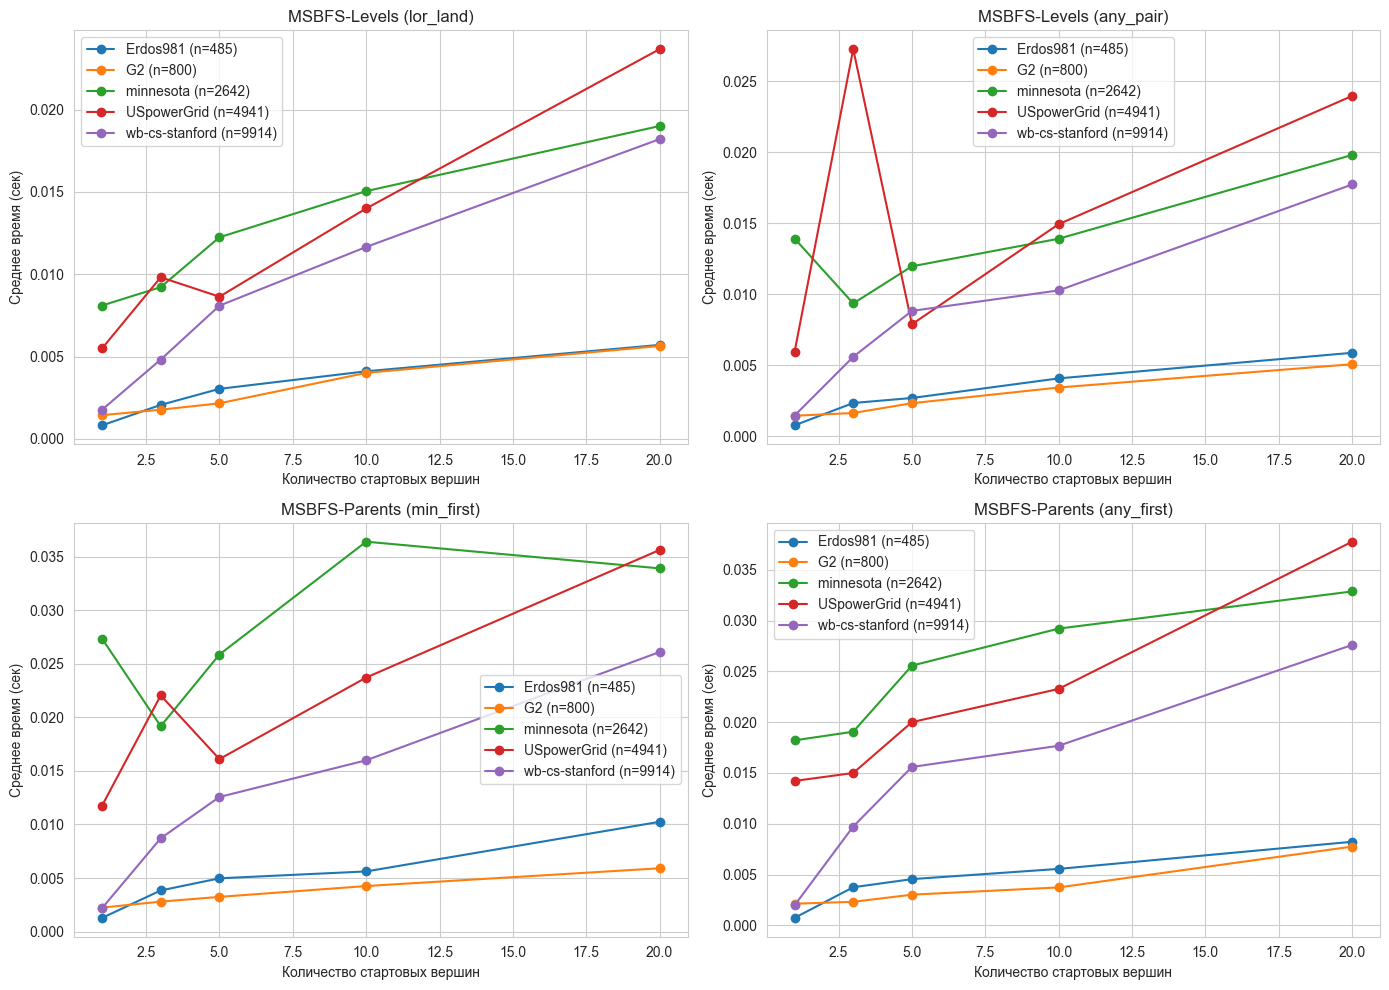

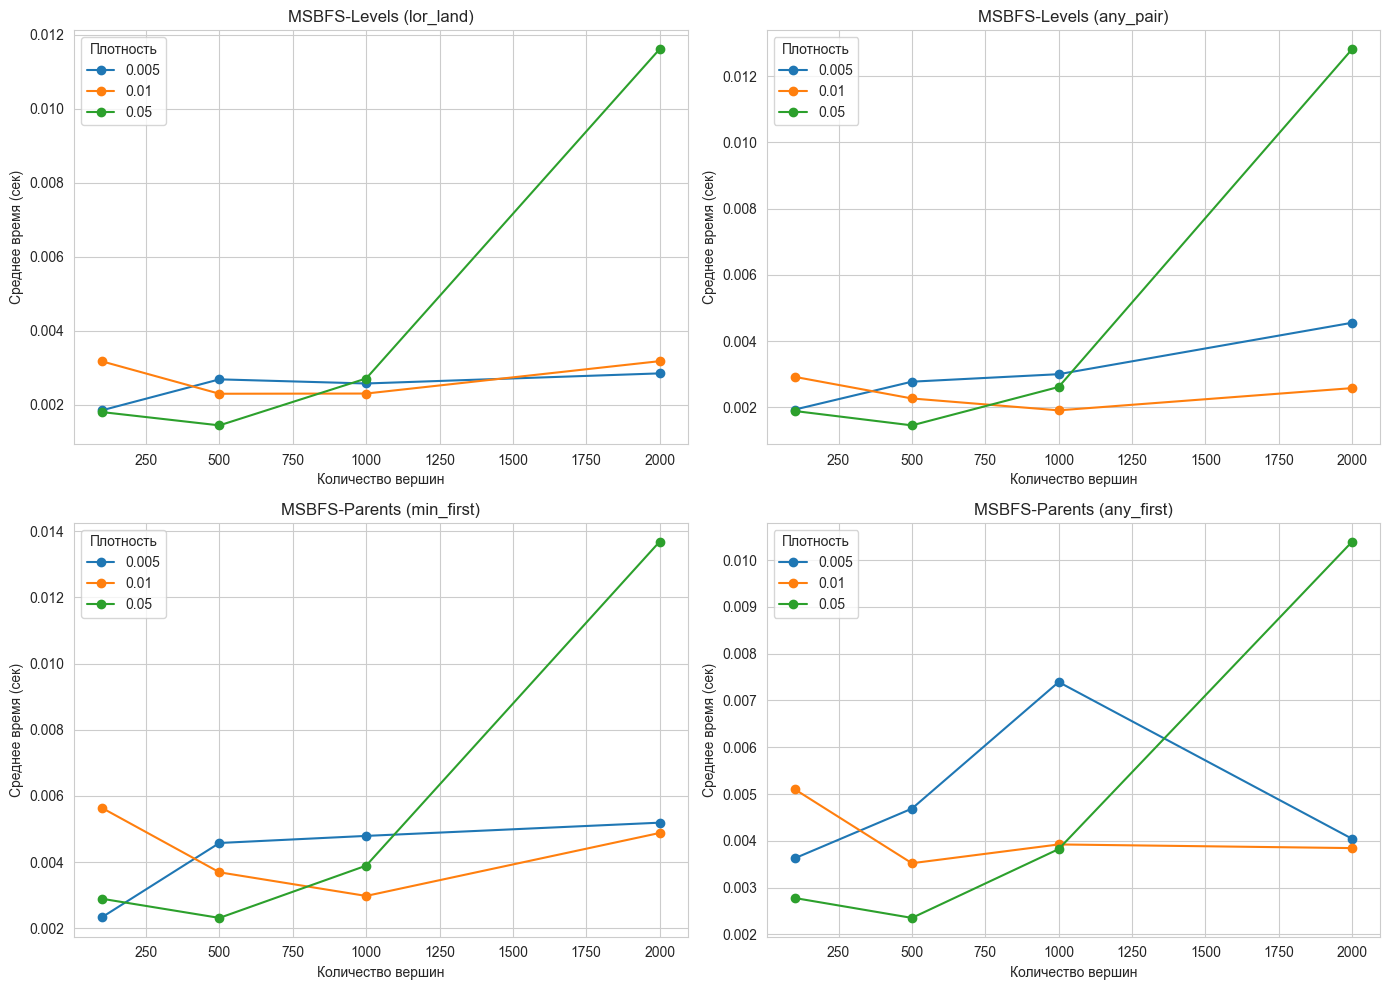

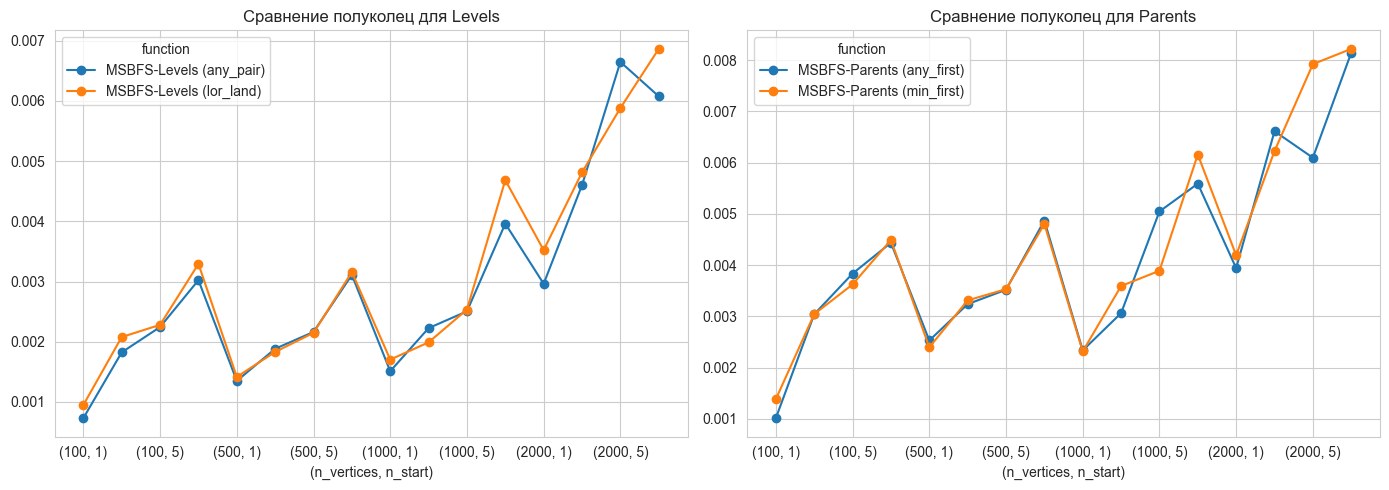

In [11]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 8)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
func_names = df_real["function"].unique()

for idx, fname in enumerate(func_names):
    ax = axes[idx//2, idx%2]
    subset = df_real[df_real["function"] == fname]
    for gname in subset["graph_name"].unique():
        data = subset[subset["graph_name"] == gname]
        ax.plot(data["n_start"], data["avg_time_sec"], marker='o', label=f"{gname} (n={data['n_vertices'].iloc[0]})")
    ax.set_title(fname)
    ax.set_xlabel("Количество стартовых вершин")
    ax.set_ylabel("Среднее время (сек)")
    ax.legend()
    ax.grid(True)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for idx, fname in enumerate(func_names):
    ax = axes[idx//2, idx%2]

    subset = df_random[df_random["function"] == fname]
    sub5 = subset[subset["n_start"] == 5]
    
    piv = sub5.pivot_table(index="n_vertices", columns="density", values="avg_time_sec", aggfunc="mean")
    piv.plot(marker='o', ax=ax)
    ax.set_title(fname)
    ax.set_xlabel("Количество вершин")
    ax.set_ylabel("Среднее время (сек)")
    ax.legend(title="Плотность")
    ax.grid(True)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

levels_data = df_random[df_random["function"].str.contains("Levels")]
pivot_levels = levels_data.pivot_table(index=["n_vertices", "n_start"], columns="function", values="avg_time_sec")
pivot_levels.plot(ax=ax[0], marker='o')
ax[0].set_title("Сравнение полуколец для Levels")
ax[0].set_xlabel("(n_vertices, n_start)")
ax[0].grid(True)

parents_data = df_random[df_random["function"].str.contains("Parents")]
pivot_parents = parents_data.pivot_table(index=["n_vertices", "n_start"], columns="function", values="avg_time_sec")
pivot_parents.plot(ax=ax[1], marker='o')
ax[1].set_title("Сравнение полуколец для Parents")
ax[1].set_xlabel("(n_vertices, n_start)")
ax[1].grid(True)
plt.tight_layout()
plt.show()

In [12]:
print("Сводная таблица для реальных графов (среднее время по стартам)")
summary_real = df_real.groupby(["graph_name", "function"])["avg_time_sec"].agg(['mean','std']).reset_index()
print(summary_real.to_string(index=False))

print("\nСводная таблица для случайных графов (n_start=5)")
random_subset = df_random[df_random["n_start"] == 5]
summary_random = random_subset.groupby(["n_vertices", "density", "function"])["avg_time_sec"].mean().unstack()
print(summary_random.round(4).to_string())

Сводная таблица для реальных графов (среднее время по стартам)
    graph_name                  function     mean      std
      Erdos981   MSBFS-Levels (any_pair) 0.003144 0.001927
      Erdos981   MSBFS-Levels (lor_land) 0.003153 0.001875
      Erdos981 MSBFS-Parents (any_first) 0.004558 0.002728
      Erdos981 MSBFS-Parents (min_first) 0.005190 0.003276
            G2   MSBFS-Levels (any_pair) 0.002776 0.001499
            G2   MSBFS-Levels (lor_land) 0.003010 0.001777
            G2 MSBFS-Parents (any_first) 0.003785 0.002305
            G2 MSBFS-Parents (min_first) 0.003686 0.001445
   USpowerGrid   MSBFS-Levels (any_pair) 0.015998 0.009477
   USpowerGrid   MSBFS-Levels (lor_land) 0.012324 0.007035
   USpowerGrid MSBFS-Parents (any_first) 0.022052 0.009541
   USpowerGrid MSBFS-Parents (min_first) 0.021846 0.009059
     minnesota   MSBFS-Levels (any_pair) 0.013794 0.003851
     minnesota   MSBFS-Levels (lor_land) 0.012724 0.004434
     minnesota MSBFS-Parents (any_first) 0.024985 0.

---

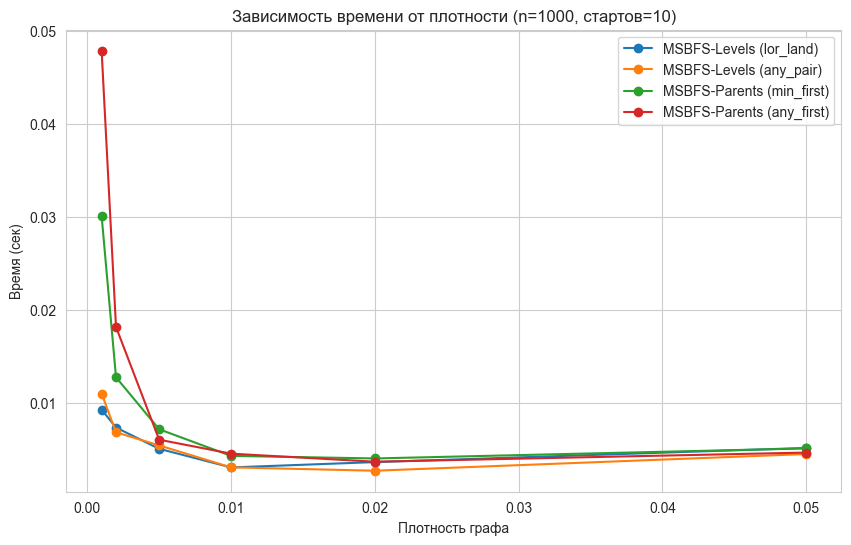

In [13]:
n_fixed = 1000
densities_test = [0.001, 0.002, 0.005, 0.01, 0.02, 0.05]
graphs_fixed = []
for d in densities_test:
    A = random_digraph_matrix(n_fixed, d, seed=123)
    graphs_fixed.append({"name": f"n{n_fixed}_d{d}", "A": A, "density": d})

results_fixed = []
for g in graphs_fixed:
    starts = np.random.choice(n_fixed, size=10, replace=False).tolist()
    for fname, f in funcs.items():
        t = time.perf_counter()
        _ = f(g["A"], starts)
        elapsed = time.perf_counter() - t
        results_fixed.append({
            "function": fname,
            "density": g["density"],
            "time_sec": elapsed
        })
df_fixed = pd.DataFrame(results_fixed)
plt.figure(figsize=(10,6))
for fname in df_fixed["function"].unique():
    sub = df_fixed[df_fixed["function"] == fname]
    plt.plot(sub["density"], sub["time_sec"], marker='o', label=fname)
plt.xlabel("Плотность графа")
plt.ylabel("Время (сек)")
plt.title(f"Зависимость времени от плотности (n={n_fixed}, стартов=10)")
plt.legend()
plt.grid(True)
plt.show()

---

Выводы:
- Видим, что у MSBFS-Levels и MSBFS-Parents базово похожие зависимости времени работы реализаций как от размера графа, так и от степени разреженности графа.
- Сравнение производительности реализаций с разными полукольцами (any.pair для levels, any.first для parents) против исходных показало, что результаты в обоих случаях очень похожи, что говорит о стабильности работы метода.

Было показано, что реализованные функции корректно работают, как на сгенерированных случайных графах, так и на реальных (с сайта [SuiteSparse Matrix Collection](https://sparse.tamu.edu/))